In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [4]:
raw_data = pd.read_csv(r"C:\Users\HP\Downloads\raw_data.csv")
raw_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,m,Yes,0,Graduate,No,5720,0.0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500.0,126.0,360.0,1.0,Uban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800.0,208.0,360.0,1.0,Urban
3,LP001035,m,Yes,2,Graduate,No,2340,2546.0,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0.0,78.0,360.0,1.0,Urban


### Understand The Data

In [7]:
# Investigate the data types present in the data
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            981 non-null    str    
 1   Gender             957 non-null    str    
 2   Married            978 non-null    str    
 3   Dependents         956 non-null    str    
 4   Education          981 non-null    str    
 5   Self_Employed      926 non-null    str    
 6   ApplicantIncome    981 non-null    int64  
 7   CoapplicantIncome  981 non-null    float64
 8   LoanAmount         954 non-null    float64
 9   Loan_Amount_Term   961 non-null    float64
 10  Credit_History     902 non-null    float64
 11  Property_Area      981 non-null    str    
dtypes: float64(4), int64(1), str(7)
memory usage: 123.6 KB


In [9]:
# Briefly get an insight about the distribution of the data (numerical values)
raw_data.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,981.0,5179.795107,5695.104533,0.0,2875.0,3800.0,5516.0,81000.0
CoapplicantIncome,981.0,1601.916330,2718.772806,0.0,0.0,1110.0,2365.0,41667.0
LoanAmount,954.0,142.511530,77.421743,9.0,100.0,126.0,162.0,700.0
Loan_Amount_Term,961.0,342.201873,65.100602,6.0,360.0,360.0,360.0,480.0
Credit_History,902.0,0.835920,0.370553,0.0,1.0,1.0,1.0,1.0


### Define the features in the dataset

In [62]:
df = raw_data.copy()

#### Features
------------------------------------------------------------------
- **Loan_ID**: A unique identifier assigned to each specific loan application
- **Gender**: The gender of the borrower/loan applicant (male or female)
- **Married**: The marital status of the borrower (Yes or No)
- **Dependents**: Number of family members dependent on the borrower
- **Education**: Educational qualification of the borrower (Graduate or Not Graduate)
- **Self_Employed**: Employment type (Yes for a business owner and No for salaried employees)
- **ApplicantIncome**: Annual income of the borrower
- **CoapplicantIncome**: Annual income of co-applicant (the spouse or family member of the borrower)
- **LoanAmount**: The total amount requested by the borrower
- **Loan_Amount_Term**: The duration of the loan in months (The borrower is expected to pay back the laon after this period)
- **Credit_History**: Record of whether the borrower met past credit guidelines (1 = good credit history/no defaults, 0 = bad credit history/prior default).
- **Property_Area**: Location type of the property being financed or put up as collateral (Urban, Semiurban, Rural).

**NOTE**: Assume that the ApplicantIncome, CoapplicantIncome, and LoanAmount is in thousands of naira

## Creditly

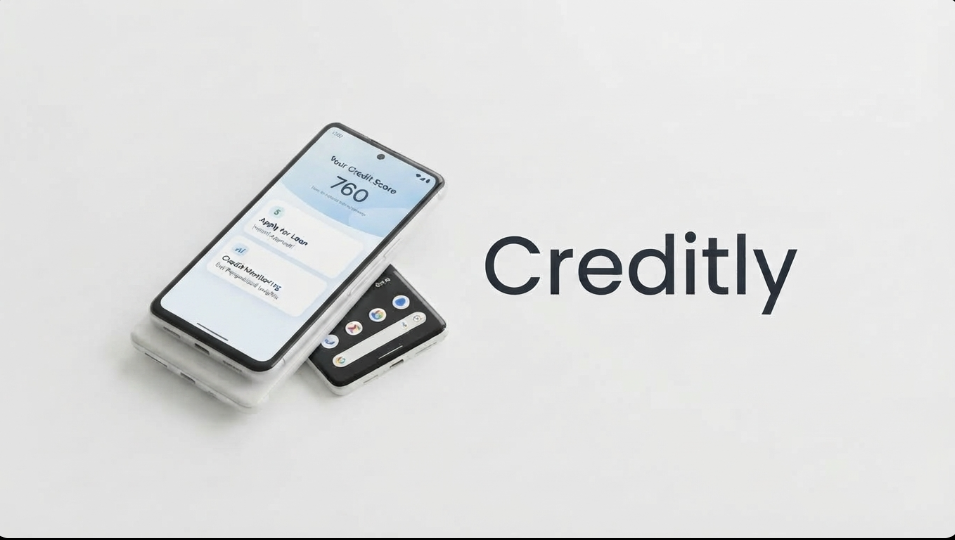

**LoanPay** recently launched **Creditly**, its digital loan application platform, backed by an aggressive marketing campaign designed to drive loan applications.

LoanPay's objective is to attract applicants who are likely to repay reliably. A surge in applications means nothing and can even be dangerous if the campaign disproportionately pulls in high-risk profiles rather than the financially sound customers LoanPay intends to reach. 

Now that **Creditly** has a pool of applicant data, the risk and marketing teams want to step back and ask, **"Who did we actually attract?"** before any lending decisions or further campaign spend are made.

---------------------------------------------------------------------------
To provide insight to the risk and marketing team, the following questions will be answered

#### Section 1: Overall Credit Quality of the Pool
- What percentage have good vs. poor credit histories?
- Is the mix healthy vs. benchmark?

#### Section 2: Who Did the Campaign Attract? (Demographics)
- Demographic breakdown (How many are male or female, how many are educated, how many are married, how many are self-employed)
- Does any segment skew toward poor credit history?

#### Section 3: Geographic Composition
- Investigate applicants by region
- Investigate credit quality by region

#### Section 4: Income & Loan Sizing Behavior
- Investigate the income distribution by credit history
- Investigate the loan amount vs. income, flagged by credit history
- Typical loan amount & term by credit history
- Average total income and loan amount by credit history

#### Section 6: Synthesis and Insights

## Data Cleaning
-------------------------------------------------------------

**Potential Issues in the Dataset**

- The naming convention for the gender values is inconsistent ('m', 'Male', 'f', 'Female')
- The ApplicantIncome should be a float for consistency since it's similar feature Coapplicantincome is already a float data type
- Credit history contains values 1 and 0, which signify good credit history and bad credit history, respectively. This feature is a binary categorical variable. The correct data type should be int or bool
- Presence of trailing white spaces and misspellings in the Property_Area column
- Loan Amount Term signifies the duration of a loan in days. The correct data type should be an integer since days cannot be represented as float numbers
- Presence of missing values

In [64]:
# The values in the Gender feature is not formatted properly
df["Gender"] = df["Gender"].replace("m","Male")
df["Gender"] = df["Gender"].replace("f","Female")

In [66]:
# Convert the applicant income to float. 
# The applicant and coapplicant income data type should be consistent
df["ApplicantIncome"] = df["ApplicantIncome"].astype(float)

In [68]:
# Convert credit history column to int (1 or 0)
df["Credit_History"] = pd.to_numeric(df["Credit_History"], errors="coerce").astype("Int64")

In [70]:
# Clean trailing/leading spaces and normalize whitespace
df['Property_Area'] = df['Property_Area'].astype(str).str.strip()

# Replace spelling variants using regex patterns
df['Property_Area'] = df['Property_Area'].replace({
    r'^U.*': 'Urban',
    r'^Semi?.*': 'Semiurban',
    r'^R.*': 'Rural'
}, regex=True)

In [264]:
# convert laon_amunt_term to int
df["Loan_Amount_Term"] = pd.to_numeric(df["Loan_Amount_Term"], errors="coerce").astype("Int64")

In [326]:
# check for duplicates
df.duplicated().any().sum()

0

## Missing Values
------------------------------------------------------------------------

In [85]:
#check for missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values/len(df)) * 100
missing_data_df = pd.DataFrame({'missing_values': missing_values,'Percentage %': missing_percentage.round(2)})
missing_data_df = missing_data_df[missing_data_df['missing_values']>0].sort_values(by='Percentage %', ascending=False)
missing_data_df

,missing_values,Percentage %
Credit_History,79,8.05
Self_Employed,55,5.61
LoanAmount,27,2.75
Dependents,25,2.55
Gender,24,2.45
Loan_Amount_Term,20,2.04
Married,3,0.31


<Figure size 1200x600 with 0 Axes>

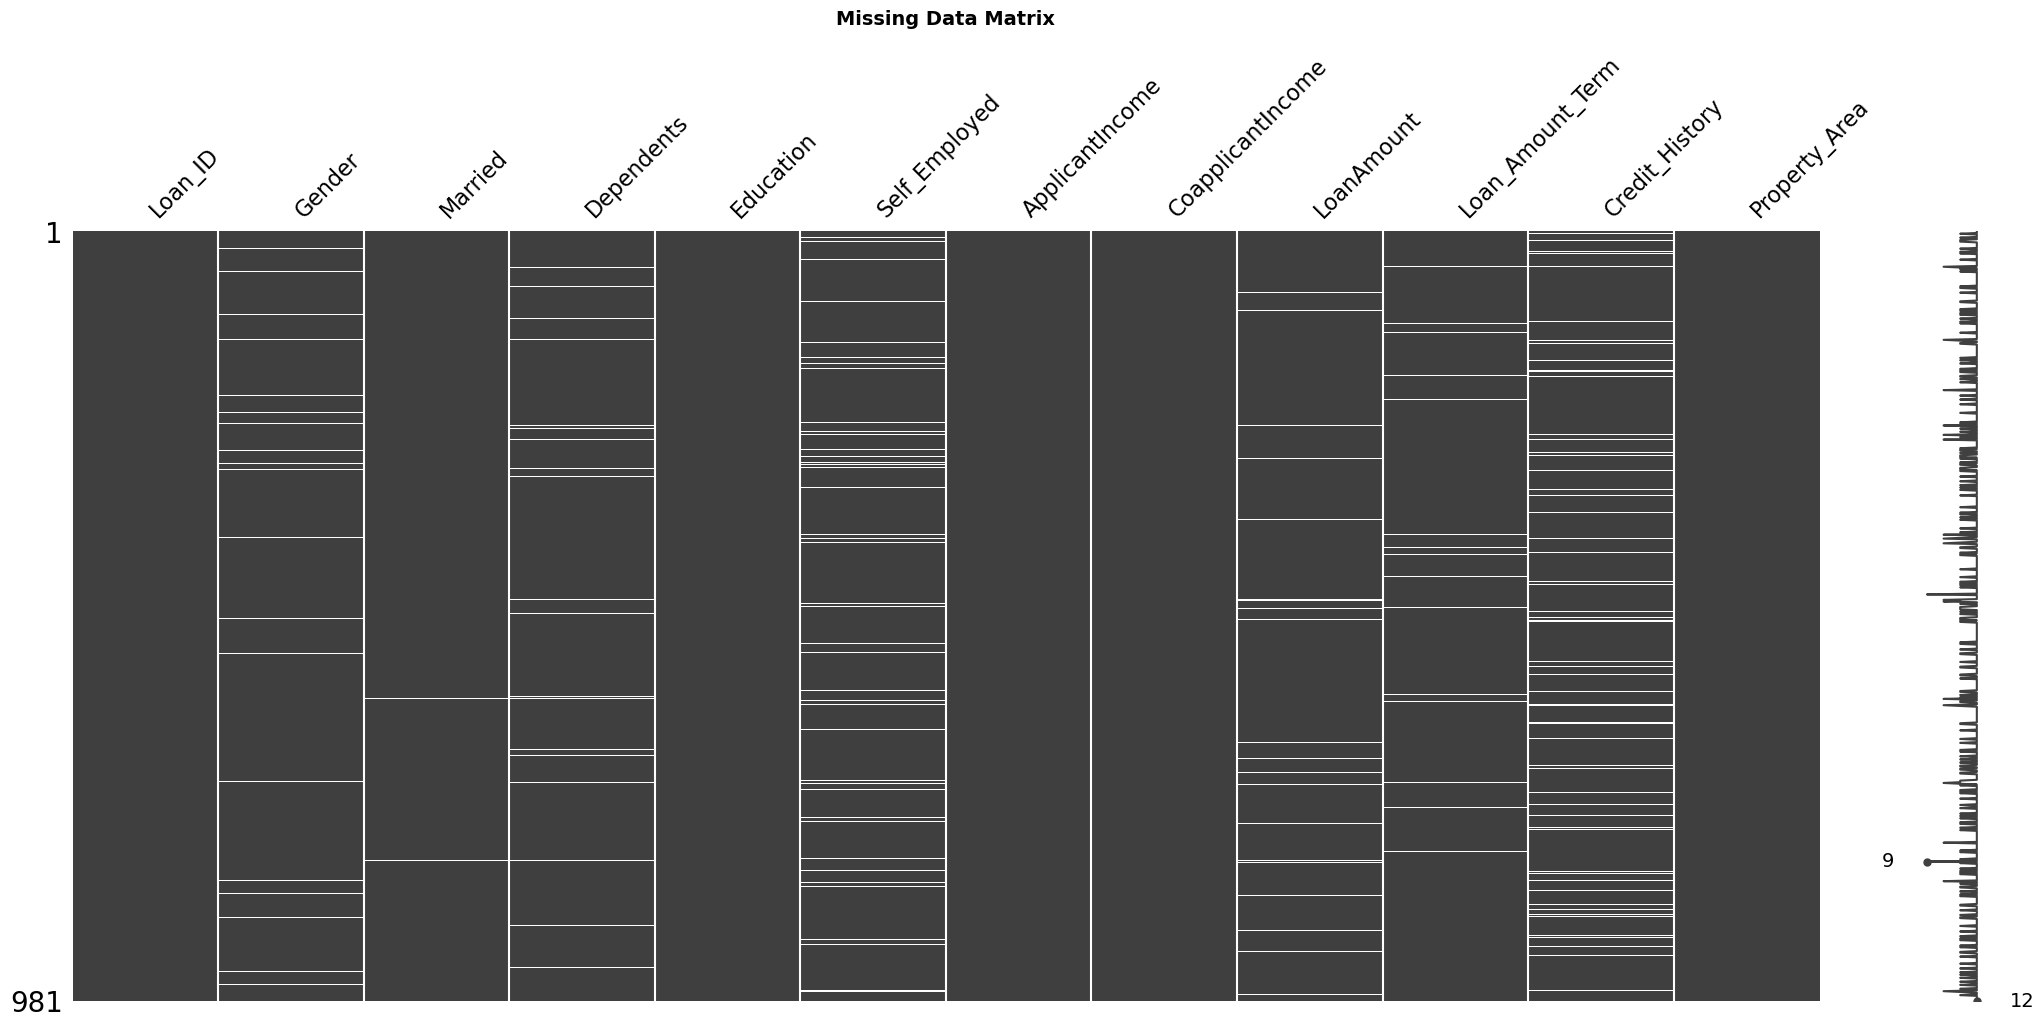

In [95]:
# Plot a missingno matrix to investigate if the missingness in one feature is related to other features
plt.figure(figsize=(12, 6))
msno.matrix(df, sparkline=True, color=(0.25, 0.25, 0.25))
plt.title('Missing Data Matrix', fontsize=14, fontweight='bold', pad=20)
plt.show()

------------------------------------------------------------------------
From the matrix above, the missingness in the columns **Married** and **Dependents** shows some correlation. Married had only 3 missing values, and in those cases the value for the dependent column was also missing.


Because this is an exploratory analysis focused on describing the observed applicant pool and answering specific business questions, rather than building a predictive model, imputing values—particularly **Credit_History** would introduce assumptions about information that was not actually observed and could distort the distributions and relationships in the data. Instead, I retained missing values as unknown where appropriate and excluded observations only from analyses that required the missing variable.


In [210]:
#fill the missing values in gender with Unknown
df["Gender"] = df["Gender"].fillna("Unknown")

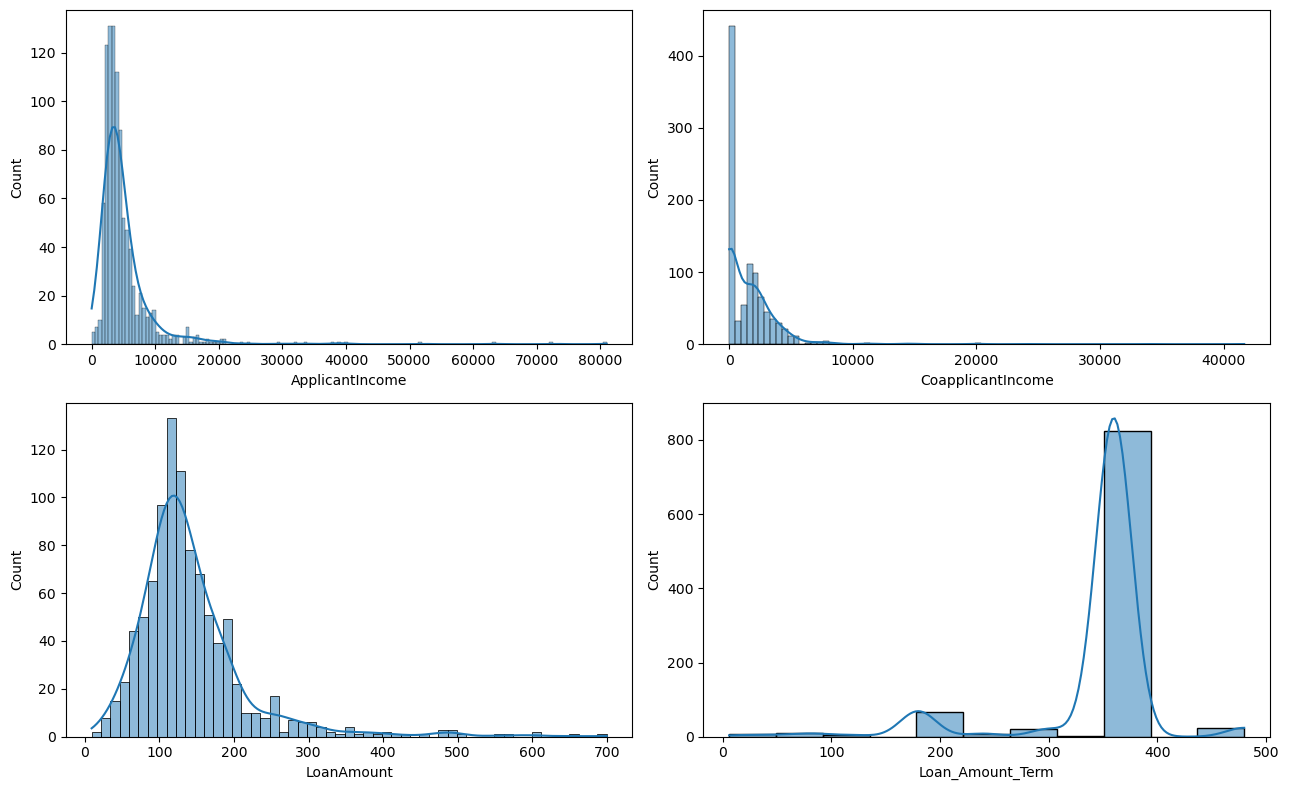

In [120]:
 # Lets visualize the histogram of the numeric data
fig, axes = plt.subplots(2,2,figsize=(13,8))

sns.histplot(df["ApplicantIncome"],kde=True,ax=axes[0,0])
axes[0,0].set_xlabel("ApplicantIncome")

sns.histplot(df["CoapplicantIncome"],kde=True,ax=axes[0,1])
axes[0,1].set_xlabel("CoapplicantIncome")

sns.histplot(df["LoanAmount"],kde=True,ax=axes[1,0])
axes[1,0].set_xlabel("LoanAmount")

sns.histplot(df["Loan_Amount_Term"],kde=True,ax=axes[1,1])
axes[1,1].set_xlabel("Loan_Amount_Term")

plt.tight_layout()
plt.show()

The histogram helps visualize the distribution of the data

The Incomes and LoanAmount plot indicates that the features are skewed. This means they contain outliers

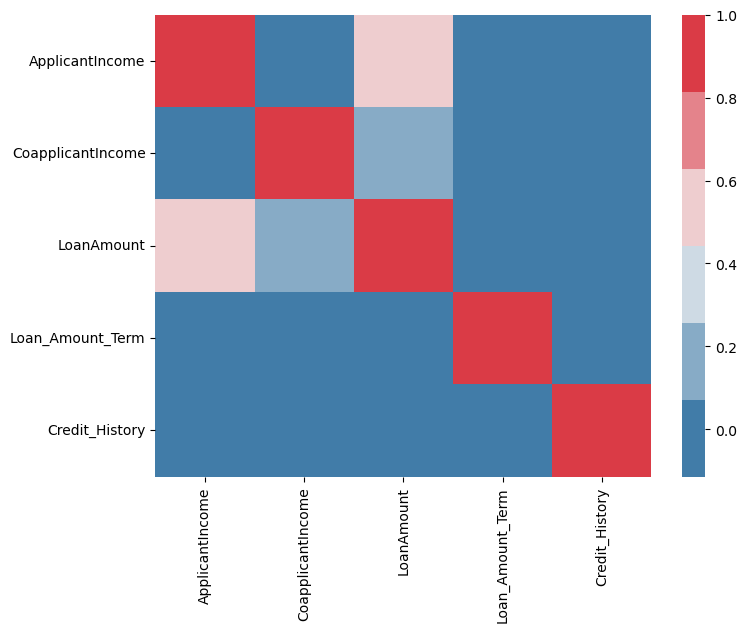

In [124]:
#correlation analysis
heat_num = df.drop(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education','Self_Employed','Property_Area'],axis=1)
plt.figure(figsize=(8,6))
sns.heatmap(data=heat_num.corr(),annot=False, cbar=True, cmap=sns.diverging_palette(240,10))
plt.show()

The heatmap shows that there is a positive correlation between loan amount and applicant income

### Section 1
-----------------------------------------------------

What percentage have good vs. poor credit histories?

In [129]:
# Exclude missing values from the data
credit_df = df.dropna(subset=["Credit_History"])

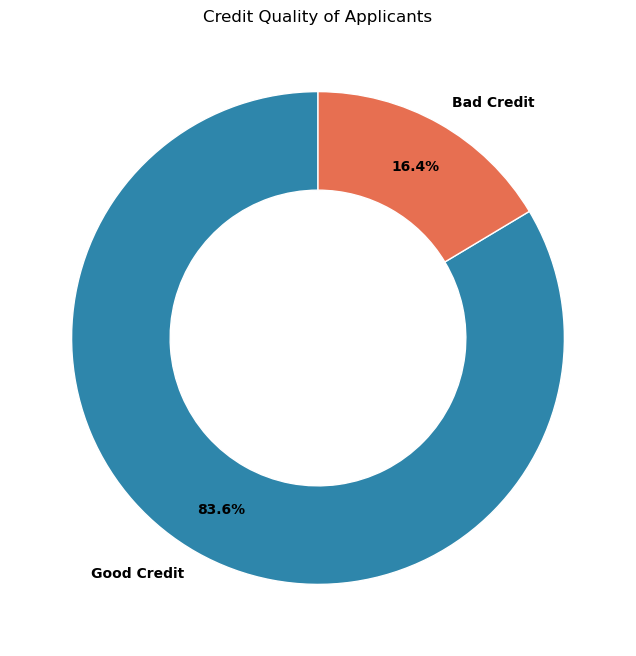

In [161]:
# Count each credit category
credit_counts = credit_df['Credit_History'].value_counts()
labels = ['Good Credit', 'Bad Credit']

# Values: 1 = Good, 0 = Bad
values = [
    credit_counts.get(1, 0),
    credit_counts.get(0, 0)
]

# Create donut chart
plt.figure(figsize=(10, 8))

plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#2E86AB', '#E76F51'],
    wedgeprops={'width': 0.4, 'edgecolor': 'white'},
    pctdistance=0.8,                                
    textprops={'color': 'black', 'weight': 'bold'}  
)

plt.title('Credit Quality of Applicants')
plt.show()

The marketing campaign run by LaonPay for the Creditly application appears to have attracted more customers who have a good credit history. During the marketing campaign, the team projected that at least 80% of the customer pool have a good credit history. The pie chart shows they exceeded this benchmark by nearly **4%**

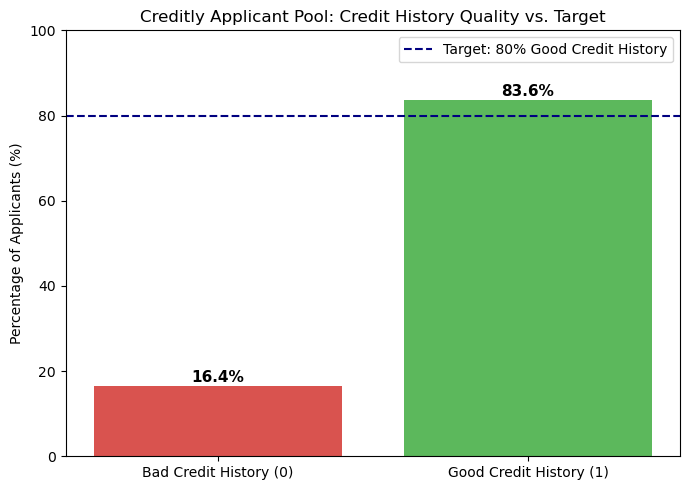

In [296]:
# Calculate percentages
credit_history_pct = credit_df['Credit_History'].value_counts(normalize=True).sort_index() * 100
labels = ['Bad Credit History (0)', 'Good Credit History (1)']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, credit_history_pct.values, color=['#d9534f', '#5cb85c'])

# Annotate each bar with its % value
for bar, pct in zip(bars, credit_history_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{pct:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Add 80% target threshold line
ax.axhline(y=80, color='navy', linestyle='--', linewidth=1.5, label='Target: 80% Good Credit History')

ax.set_ylabel('Percentage of Applicants (%)')
ax.set_title('Creditly Applicant Pool: Credit History Quality vs. Target')
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.show()

### Section 2
-------------------------------------------------

Demographic breakdown (How many are male or female, how many are educated, how many are married, how many are self-employed)

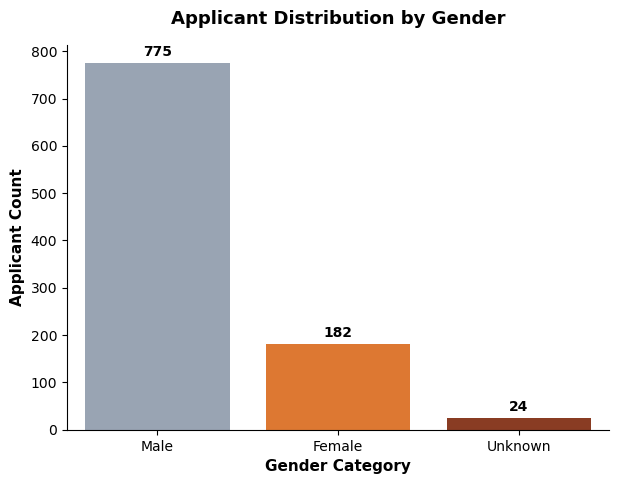

In [186]:
#countplot of gender
gender_series = df["Gender"].fillna("Unknown")

fig, ax = plt.subplots(figsize=(7, 5))

sns.countplot(x=gender_series, hue = gender_series, palette=['#94A3B8', '#F97316', '#9A3412'], ax=ax)

# Annotate exact counts on top of each bar
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3), textcoords='offset points')

# Format plot labels and symmetry
ax.set_title('Applicant Distribution by Gender', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Gender Category', fontsize=11, fontweight='bold')
ax.set_ylabel('Applicant Count', fontsize=11, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)  

plt.show()

The missing values in the Gender column were excluded during the analysis. 

**Insight**: The majority of the customers that use **Creditly** for their loan application are males (775), while the gender of 24 customers was unidentified

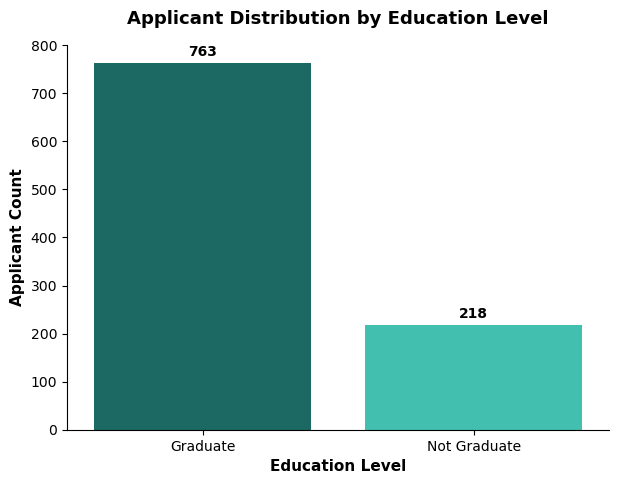

In [299]:
#countplot of Education status
fig, ax = plt.subplots(figsize=(7, 5))

sns.countplot(x=df["Education"], hue=df["Education"], palette=['#0F766E', '#2DD4BF'],ax=ax)

# Annotate exact counts on top of each bar
for p in ax.patches:
    height = int(p.get_height())
    if height > 0:
        ax.annotate(
            f'{height}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            xytext=(0, 3), textcoords='offset points'
        )

# Format plot labels and symmetry
ax.set_title('Applicant Distribution by Education Level', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Education Level', fontsize=11, fontweight='bold')
ax.set_ylabel('Applicant Count', fontsize=11, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.show()

**Insight**: The plot shows that Creditly customers at least have a first degree

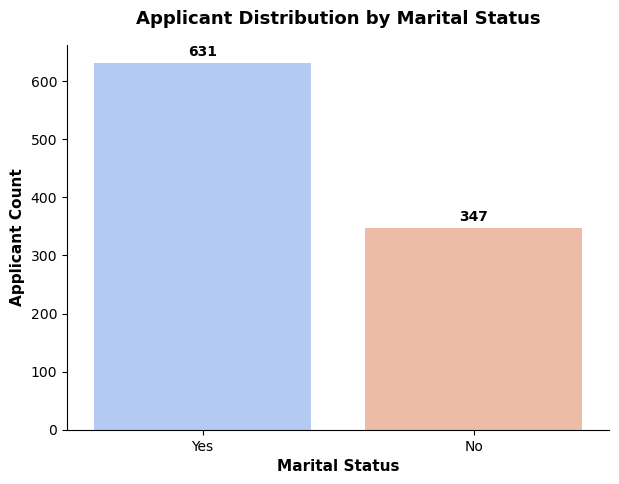

In [202]:
#count plot of married applicants
married_df = df.dropna(subset=["Married"])

fig, ax = plt.subplots(figsize=(7, 5))

# Seaborn countplot for Married status (excluding missing values)
sns.countplot(x=married_df["Married"], hue=married_df["Married"], palette="coolwarm", ax=ax)

# Annotate exact counts on top of each bar
for p in ax.patches:
    height = int(p.get_height())
    if height > 0:
        ax.annotate(
            f'{height}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            xytext=(0, 3), textcoords='offset points'
        )

# Format plot labels and symmetry
ax.set_title('Applicant Distribution by Marital Status', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Marital Status', fontsize=11, fontweight='bold')
ax.set_ylabel('Applicant Count', fontsize=11, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.show()

**Insight**: The plot indicates that more of Creditly customers are married

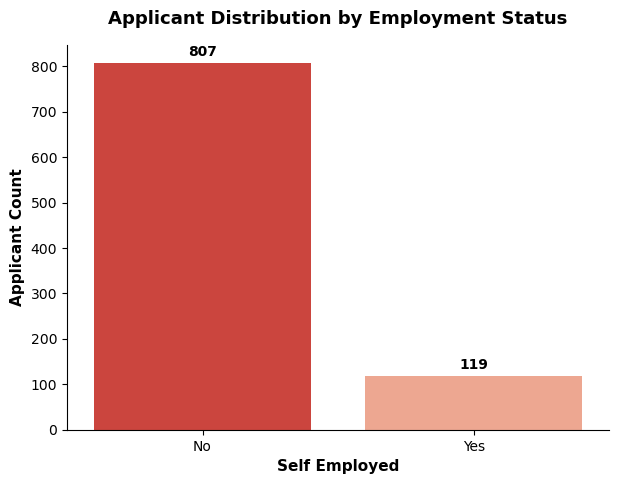

In [206]:
#count plot of applicants employment status
self_employed_df = df.dropna(subset=["Self_Employed"])

fig, ax = plt.subplots(figsize=(7, 5))

# Seaborn countplot for Self_Employed status
sns.countplot(x=self_employed_df["Self_Employed"],hue=self_employed_df["Self_Employed"],palette="Reds_r", ax=ax)

# Annotate exact counts on top of each bar
for p in ax.patches:
    height = int(p.get_height())
    if height > 0:
        ax.annotate(
            f'{height}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            xytext=(0, 3), textcoords='offset points'
        )

# Format plot labels and symmetry
ax.set_title('Applicant Distribution by Employment Status', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Self Employed', fontsize=11, fontweight='bold')
ax.set_ylabel('Applicant Count', fontsize=11, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.show()

**Insight**: The plot shows that more of Creditly customers are salary earners

Does any segment (education, marriage, employment status, and gender) skew toward poor credit history?

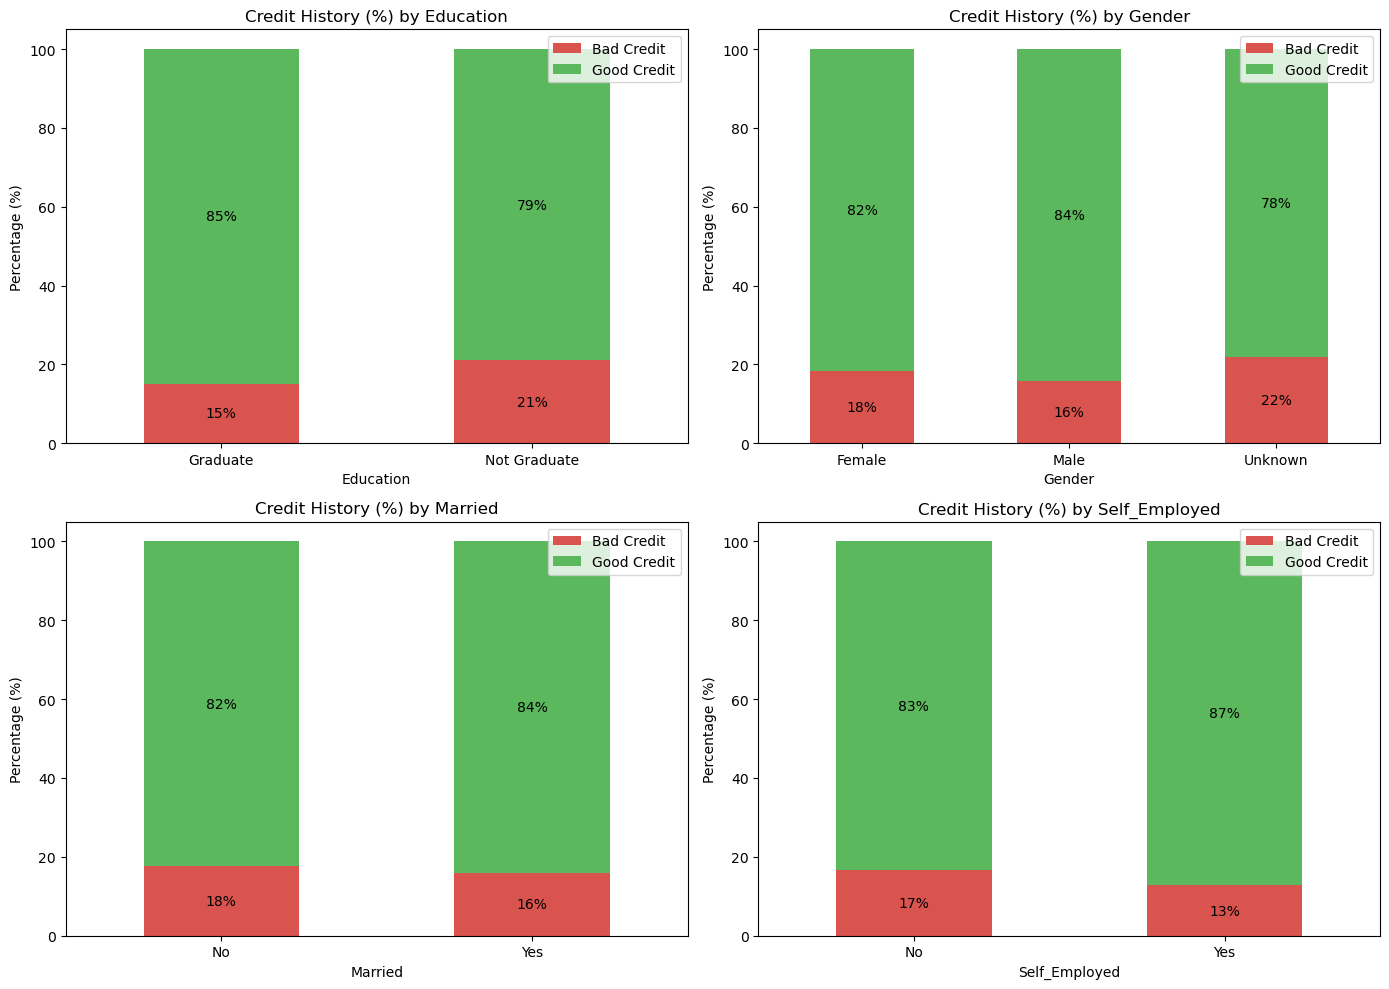

In [216]:
# Map each variable to its corresponding cleaned dataframe
demographic_dfs = {
    'Education': df,              # no missing values
    'Gender': df,          # missing filled with 'Unknown'
    'Married': married_df,        # missing rows excluded
    'Self_Employed': self_employed_df  # missing rows excluded
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (var, data) in enumerate(demographic_dfs.items()):
    ct = pd.crosstab(data[var], data['Credit_History'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#d9534f', '#5cb85c'])
    
    axes[i].set_title(f'Credit History (%) by {var}')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xlabel(var)
    axes[i].legend(['Bad Credit', 'Good Credit'], loc='upper right')
    axes[i].tick_params(axis='x', rotation=0)
    
    for c in axes[i].containers:
        axes[i].bar_label(c, fmt='%.0f%%', label_type='center')

plt.tight_layout()
plt.show()

The plot clearly shows that more customers skew towards a good credit history

### Section 3: Geographic Composition
---------------------------------------------------------------------------

Investigate applicants by property_area

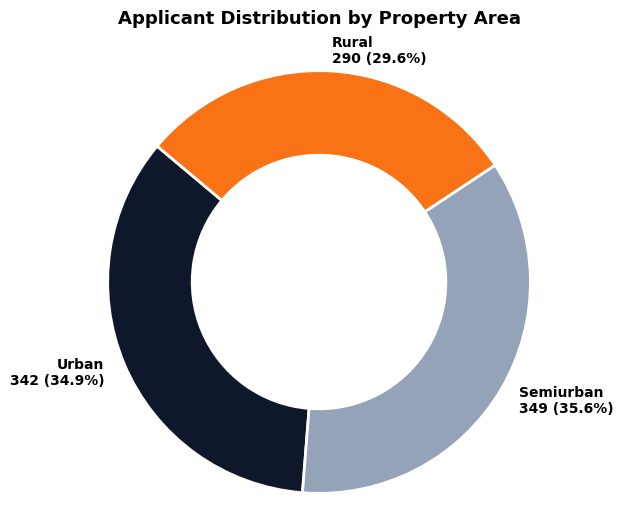

In [224]:
# Compute exact counts ordered by Urban, Semiurban, Rural
area_order = ['Urban', 'Semiurban', 'Rural']
area_counts = df['Property_Area'].value_counts().reindex(area_order)

# Format labels with counts and percentages
total = len(df)
labels = [f'{area}\n{count} ({count/total*100:.1f}%)' for area, count in area_counts.items()]
colors = ['#0F172A', '#94A3B8', '#F97316']

#Setup figure using subplots for clean aspect ratio control
fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(
    area_counts,
    labels=labels,
    startangle=140,
    colors=colors,
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 10, 'fontweight': 'bold'}
)

ax.axis('equal')  
plt.title('Applicant Distribution by Property Area', fontsize=13, fontweight='bold', pad=20)

plt.show()

**Insight**: The customers using Creditly for loan applications put their properties as collateral. According to the data, these properties can be in a rural, semiurban, or urban area. 

Assumption: The customers live at the same location as the properties used as collateral

Therefore, the plot tells us that more of Creditly customers are from the semi-urban area, followed by the urban area

Investigate credit quality by propert_area

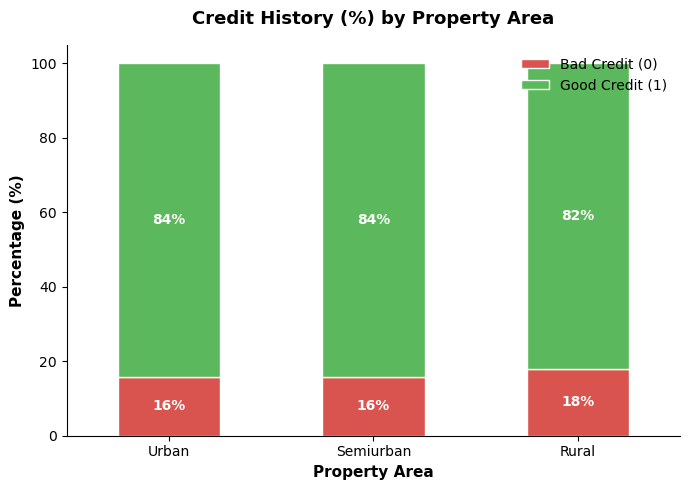

In [306]:
# Compute normalized cross-tabulation on credit_df
ct = pd.crosstab(credit_df['Property_Area'], credit_df['Credit_History'], normalize='index') * 100
ct = ct.reindex(['Urban', 'Semiurban', 'Rural'])

fig, ax2 = plt.subplots(figsize=(7, 5))

#Plot stacked bar chart 
ct.plot(kind='bar', stacked=True, ax=ax2, color=['#d9534f', '#5cb85c'], width=0.5, edgecolor='white')

ax2.set_title('Credit History (%) by Property Area', fontsize=13, fontweight='bold', pad=15)
ax2.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Property Area', fontsize=11, fontweight='bold')
ax2.tick_params(axis='x', rotation=0)
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(['Bad Credit (0)', 'Good Credit (1)'], loc='upper right', frameon=False)

# Annotate stacked bar segments with rounded integer percentages
for c in ax2.containers:
    # Only label real bar containers, skip non-bar artists
    if hasattr(c, 'patches'):
        ax2.bar_label(c, fmt='%.0f%%', label_type='center', fontweight='bold', color='white', fontsize=10)

plt.tight_layout()
plt.show()

**Insight**: According to the data, the majority of the customers living in these different areas have a good credit history

### Section 4: Income & Loan Sizing Behavior
--------------------------------------------------------------------

Investigate the income distribution by credit history.

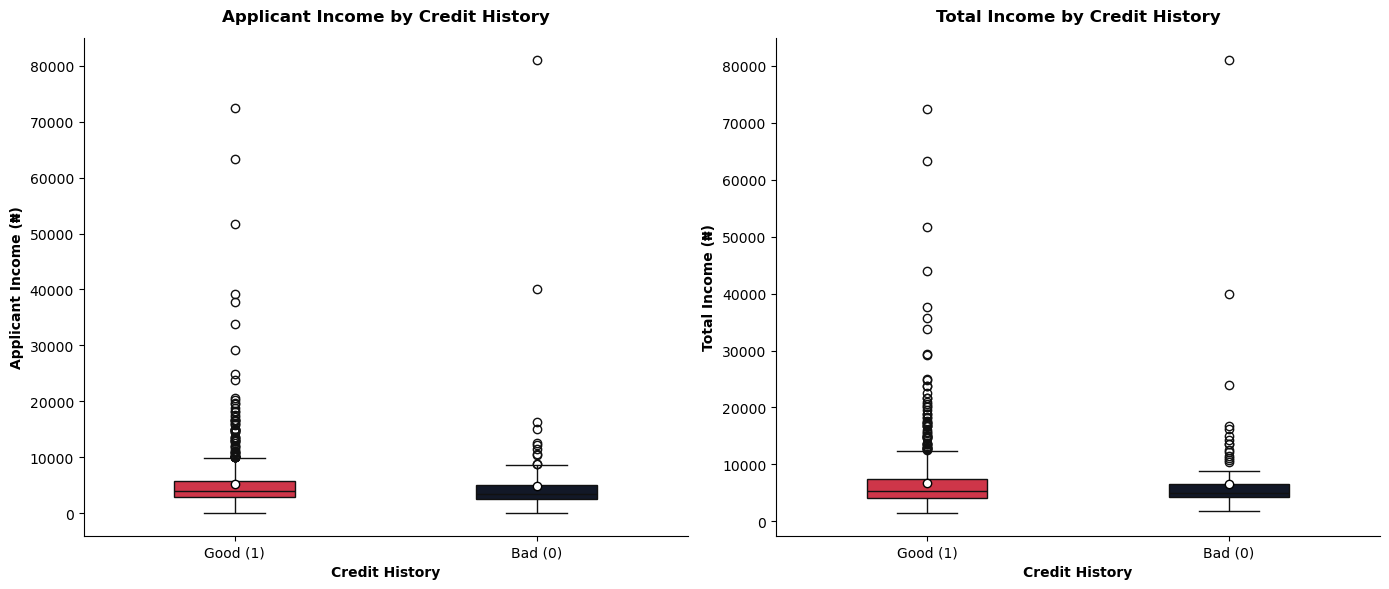

In [315]:
# Compute Total Income for a complete financial picture
credit_df['Total_Income'] = credit_df['ApplicantIncome'] + credit_df['CoapplicantIncome']

# Map credit history for clear plot labeling
credit_df['Credit_Label'] = credit_df['Credit_History'].map({1.0: 'Good (1)', 0.0: 'Bad (0)'})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#E71D36', '#0F172A']

# Plot 1: Applicant Income vs Credit History 
sns.boxplot(
    data=credit_df,
    x='Credit_Label',
    hue='Credit_Label',
    y='ApplicantIncome',
    palette=colors,
    ax=axes[0],
    width=0.4,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"})

axes[0].set_title('Applicant Income by Credit History', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Credit History', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Applicant Income (₦)', fontsize=10, fontweight='bold')
axes[0].spines[['top', 'right']].set_visible(False)

# Optional: Set y-limit to focus on 95th percentile if extreme outliers compress the box
#axes[0].set_ylim(0, credit_df['ApplicantIncome'].quantile(0.95))

# Total Income vs Credit History 
sns.boxplot(
    data=credit_df,
    x='Credit_Label',
    hue = "Credit_Label",
    y='Total_Income',
    palette=colors,
    ax=axes[1],
    width=0.4,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"}
)
axes[1].set_title('Total Income by Credit History', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Credit History', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Total Income (₦)', fontsize=10, fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

# Optional: Set y-limit to focus on 95th percentile
#axes[1].set_ylim(0, credit_df['Total_Income'].quantile(0.95))

plt.tight_layout()
plt.show()

**Insight**: Applicants with good credit history and applicants with bad credit history make almost the exact same amount of money on average. This points to the fact that for this set of applicants the income alone does not really determine if they will default on their loan

Investigate the loan amount vs. income, flagged by credit history

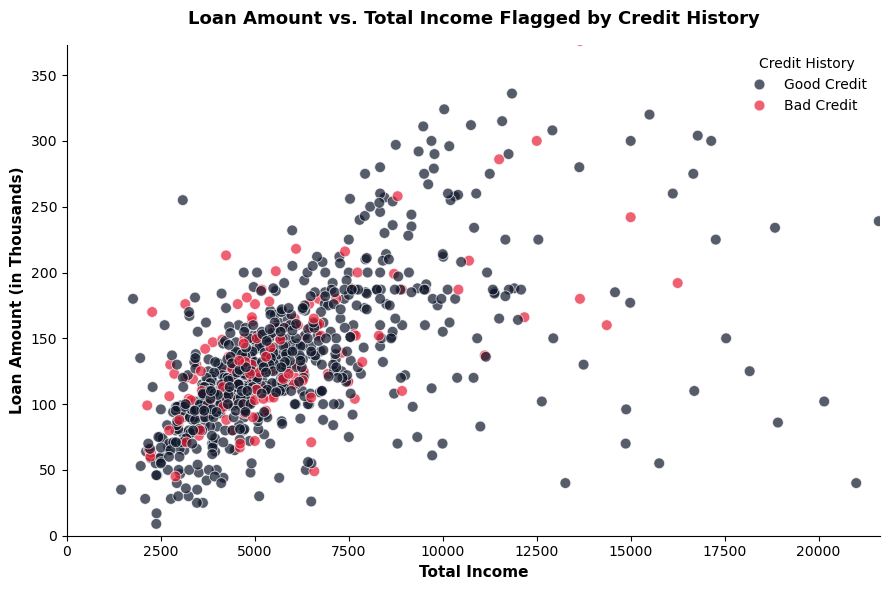

In [249]:
# Handle missing coapplicant income & create Total_Income
plot_df = df.copy()
plot_df['Total_Income'] = plot_df['ApplicantIncome'] + plot_df['CoapplicantIncome']

# Drop missing values strictly for this visualization
plot_df = plot_df.dropna(subset=['LoanAmount', 'Credit_History'])

# Map Credit History to clean categorical labels
plot_df['Credit_Label'] = plot_df['Credit_History'].map({1.0: 'Good Credit', 0.0: 'Bad Credit'})

# Setup figure canvas
fig, ax = plt.subplots(figsize=(9, 6))
colors = {'Bad Credit': '#E71D36', 'Good Credit': '#0F172A'}

# Scatter Plot: Total Income vs. Loan Amount
sns.scatterplot(data=plot_df, x='Total_Income', y='LoanAmount', hue='Credit_Label',palette=colors,alpha=0.7,s=60,edgecolor='white',ax=ax)

ax.set_title('Loan Amount vs. Total Income Flagged by Credit History', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Total Income', fontsize=11, fontweight='bold')
ax.set_ylabel('Loan Amount (in Thousands)', fontsize=11, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(title='Credit History', frameon=False, loc='upper right')

# Focus on 98th percentile to avoid compression from extreme income outliers
ax.set_xlim(0, plot_df['Total_Income'].quantile(0.98))
ax.set_ylim(0, plot_df['LoanAmount'].quantile(0.98))

plt.tight_layout()
plt.show()

**Insight**: While loan amounts scale with income, bad credit history is uniformly distributed across all income levels and loan sizes, proving that income level alone does not reduce default risk.

Typical loan amount & term by credit history

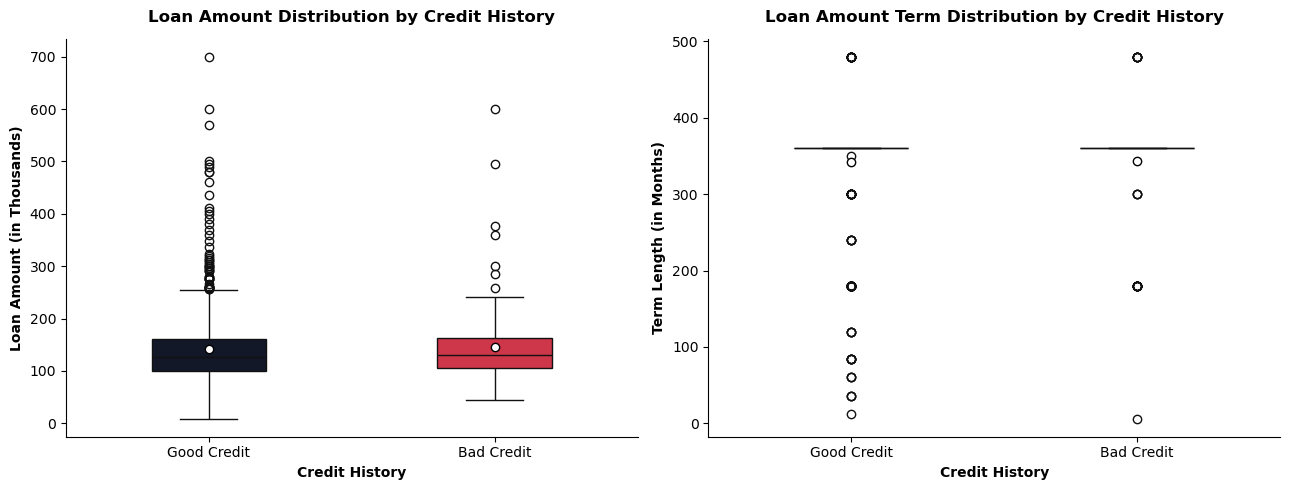

In [318]:
# drop rows with missing values in target features
clean_loan_df = df.dropna(subset=['LoanAmount', 'Loan_Amount_Term', 'Credit_History']).copy()

# Map Credit History to clean categorical labels
clean_loan_df['Credit_Label'] = clean_loan_df['Credit_History'].map({1.0: 'Good Credit', 0.0: 'Bad Credit'})

# Setup 1x2 subplot layout
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {'Bad Credit': '#E71D36', 'Good Credit': '#0F172A'}

# Subplot 1:Loan Amount by Credit History 
sns.boxplot(
    data=clean_loan_df,
    x='Credit_Label',
    y='LoanAmount',
    hue='Credit_Label',
    palette=colors,
    legend=False,
    ax=axes[0],
    width=0.4,
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black"}
)
axes[0].set_title('Loan Amount Distribution by Credit History', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Credit History', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Loan Amount (in Thousands)', fontsize=10, fontweight='bold')
axes[0].spines[['top', 'right']].set_visible(False)

# Focus on 98th percentile to keep boxplot readable despite high outliers
#axes[0].set_ylim(0, clean_loan_df['LoanAmount'].quantile(0.98))

# Subplot 2: Loan Amount Term by Credit History
sns.boxplot(
    data=clean_loan_df,
    x='Credit_Label',
    y='Loan_Amount_Term',
    hue='Credit_Label',
    palette=colors,
    legend=False,
    ax=axes[1],
    width=0.4,
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black"}
)
axes[1].set_title('Loan Amount Term Distribution by Credit History', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Credit History', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Term Length (in Months)', fontsize=10, fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**Insight**: Neither loan amount size nor repayment term length influences credit standing, as applicants with good and bad credit histories request nearly identical loan amounts and standardized 360-month loan terms.

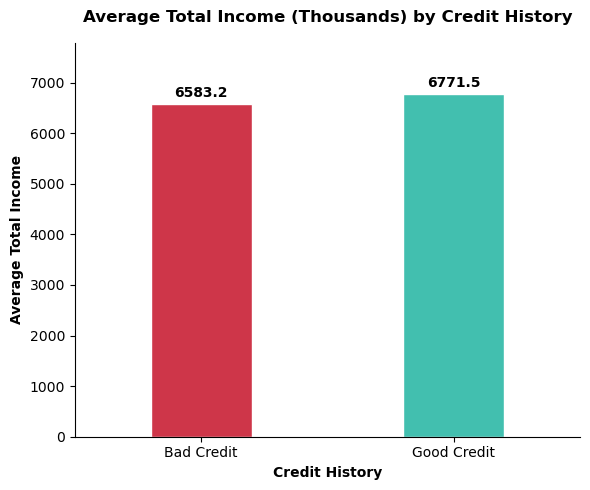

In [345]:
# Calculate Total Income & drop missing Credit_History
plot_df = df.copy()
plot_df['Total_Income'] = plot_df['ApplicantIncome'] + plot_df['CoapplicantIncome']

# Exclude missing values strictly for Credit_History
clean_df = plot_df.dropna(subset=['Credit_History']).copy()

# Map Credit History to clean categorical labels
clean_df['Credit_Label'] = clean_df['Credit_History'].map({1: 'Good Credit', 0: 'Bad Credit'})

# Compute Group Averages
avg_income_df = clean_df.groupby('Credit_Label')['Total_Income'].mean().reset_index()

fig, ax = plt.subplots(figsize=(6, 5))
colors = {'Bad Credit': '#E71D36', 'Good Credit': '#2DD4BF'}

# Bar Plot
sns.barplot(data=avg_income_df, x='Credit_Label', y='Total_Income', hue='Credit_Label', palette=colors, legend=False, ax=ax, width=0.4, edgecolor='white')

# Formatting & Value Annotations
ax.set_title('Average Total Income (Thousands) by Credit History', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Credit History', fontsize=10, fontweight='bold')
ax.set_ylabel('Average Total Income', fontsize=10, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

# Add exact numeric values above each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontweight='bold', fontsize=10)

# Expand y-axis limit for label spacing
ax.set_ylim(0, avg_income_df['Total_Income'].max() * 1.15)

plt.tight_layout()
plt.show()

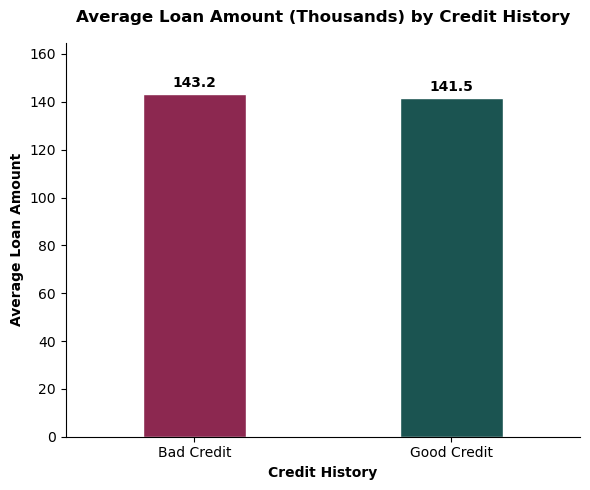

In [347]:
# Prepare Data & drop missing Credit_History & LoanAmount
cl_df = df.dropna(subset=['Credit_History', 'LoanAmount']).copy()

# Map Credit History to clean categorical labels
cl_df['Credit_Label'] = cl_df['Credit_History'].map({1: 'Good Credit', 0: 'Bad Credit'})

# Compute Group Averages
avg_loan_df = cl_df.groupby('Credit_Label')['LoanAmount'].mean().reset_index()

fig, ax = plt.subplots(figsize=(6, 5))
colors = {'Bad Credit': '#9D174D', 'Good Credit': '#115E59'}

sns.barplot(data=avg_loan_df, x='Credit_Label', y='LoanAmount', hue='Credit_Label', palette=colors, legend=False, ax=ax,
    width=0.4,
    edgecolor='white'
)

# Formatting & Value Annotations
ax.set_title('Average Loan Amount (Thousands) by Credit History', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Credit History', fontsize=10, fontweight='bold')
ax.set_ylabel('Average Loan Amount', fontsize=10, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

# Add exact numeric values above each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontweight='bold', fontsize=10)

# Expand y-axis limit for label spacing
ax.set_ylim(0, avg_loan_df['LoanAmount'].max() * 1.15)

plt.tight_layout()
plt.show()

**Insight**: The average taotal income and average loan amount for applicants with good and bad credit history are very close.

In [354]:
#save cleaned data
df.to_csv("cleaned_data.csv")
print("Saved Successfully!")

Saved Successfully!
